## Импорты

In [1]:
import pandas as pd
import numpy as np
import time
import kagglehub
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from math import sqrt
from xgboost import XGBRegressor
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import make_forecasting_frame, impute
from prophet import Prophet

## Загрузка данных

In [41]:
# Gold Price dataset
path = kagglehub.dataset_download("nisargchodavadiya/daily-gold-price-20152021-time-series")

gold_price_file = "Gold Price.csv"
gold_data = pd.read_csv(gold_price_file, parse_dates=["Date"])[["Date", "Price"]]
gold_data

100%|██████████| 46.6k/46.6k [00:00<00:00, 216kB/s]

Extracting files...


FileNotFoundError: [Errno 2] No such file or directory: 'Gold Price.csv'

In [3]:
# GTrends dataset
start_date = "2014-01-01"
end_date = "2024-11-06"
keywords = [
    "gold", "inflation", "crisis", "economy", "Biden", "Trump", "Powell", "Yellen", "Putin", "Xi Jinping", 
    "climate change", "interest rates", "recession", "oil prices", "GDP", "stock market", "trade war", 
    "unemployment", "central bank", "federal reserve", "sanctions", "crypto", "blockchain", "tax policy", 
    "debt ceiling", "tariffs", "geopolitics", "renewable energy", "housing market", "real estate", "forex", 
    "gold reserves", "commodities", "energy crisis", "supply chain", "inflation rate", "economic growth", 
    "market crash", "government bonds", "quantitative easing", "austerity", "public debt", "hedge fund", 
    "pension fund", "private equity", "venture capital", "startups", "IPO", "mergers and acquisitions", 
    "dividends", "share buybacks", "stock options", "investment banking", "wealth management", "asset management", 
    "financial crisis", "credit risk", "sovereign debt", "fiscal policy", "monetary policy", "economic sanctions", 
    "globalization", "deglobalization", "foreign investment", "inflation hedge", "gold mining", "commodity trading", 
    "investment strategies", "currency exchange", "dollar index", "eurozone", "Asian markets", "BRICS", 
    "trade agreements", "NAFTA", "TPP", "EU regulations", "US-China relations", "supply chain disruptions", 
    "pandemic", "recovery", "healthcare policy", "pharmaceuticals", "biotech", "tech stocks", 
    "semiconductors", "AI development", "machine learning", "cybersecurity", "big data", "cloud computing", 
    "5G technology", "electric vehicles", "renewable resources", "solar power", "wind energy", "nuclear power", 
    "hydropower", "carbon emissions", "green energy", "environmental policy", "climate finance", "sustainable investing", 
    "social impact", "corporate governance", "ESG investing", "shareholder activism", "corporate responsibility", 
    "regulatory compliance", "fintech", "neobanks", "digital wallets", "cryptocurrency exchange", "NFTs", 
    "blockchain technology", "smart contracts", "decentralized finance", "metaverse", "virtual reality", 
    "augmented reality", "technology adoption", "consumer behavior", "retail sales", "e-commerce", "online marketplaces", 
    "logistics", "freight rates", "ocean shipping", "air freight", "rail transport", "automotive industry", 
    "supply chain management", "industrial production", "factory automation", "robotics", "IoT", "industrial IoT", 
    "smart cities", "urbanization", "population growth", "demographics", "aging population", "healthcare spending", 
    "education funding", "student debt", "workforce development", "labor market", "minimum wage", "income inequality", 
    "wealth gap", "tax reforms", "corporate tax", "inheritance tax", "offshore accounts", "wealth redistribution", 
    "public policy", "campaign finance", "election outcomes", "political stability", "international relations", 
    "defense spending", "military conflict", "peace treaties", "diplomacy", "human rights", "UN policies", 
    "World Bank", "IMF", "OECD", "global trade", "WTO", "OPEC", "energy markets", "commodity futures", 
    "options trading", "derivatives", "risk management", "portfolio optimization", "quantitative finance", 
    "behavioral finance", "market psychology", "investor sentiment", "trading volume", "market trends", 
    "technical analysis", "fundamental analysis", "earnings reports", "quarterly results", "corporate strategy", 
    "management changes", "board decisions", "mergers", "spin-offs", "divestitures", "joint ventures", 
    "strategic alliances", "competitive advantage", "market share", "brand value", "consumer loyalty", 
    "product innovation", "R&D spending", "patent filings", "intellectual property", "trademark disputes", 
    "legal risks", "litigation", "compliance risks", "cyber risks", "data breaches", "privacy concerns", 
    "ethical considerations", "corporate ethics", "whistleblowing", "regulatory scrutiny", "audit reports", 
    "transparency", "accounting standards", "financial reporting", "investor communications", "media influence"
]

pytrends = TrendReq(hl='en-US', tz=360)

def fetch_trends_data(keywords_group, start_date, end_date):
    pytrends.build_payload(keywords_group, timeframe=f"{start_date} {end_date}")
    data = pytrends.interest_over_time()
    return data.reset_index()

trend_data_list = []
for i in range(0, len(keywords), 5):
    group = keywords[i:i+5]
    trends = fetch_trends_data(group, start_date, end_date)
    trend_data_list.append(trends)
    time.sleep(5)
    
trend_data = pd.concat(trend_data_list, axis=1)
trend_data = trend_data.loc[:, ~trend_data.columns.duplicated()]

trend_data = trend_data.rename(columns={"date": "Date"})
trend_data["Date"] = pd.to_datetime(trend_data["Date"])
data = pd.merge(gold_data, trend_data, on="Date", how="left")
data = data.fillna(method="ffill").fillna(method="bfill")
data.to_csv("Gold_Price_with_Trends.csv", index=False)

TooManyRequestsError: The request failed: Google returned a response with code 429

In [213]:
output_file = "Gold_Price_with_Trends.csv"
data = pd.read_csv(output_file)
data

,Date,Price,gold,inflation,crisis,economy,Biden,isPartial,Trump,Powell,...,ethical considerations,corporate ethics,whistleblowing,regulatory scrutiny,audit reports,transparency,accounting standards,financial reporting,investor communications,media influence
0,2024-11-06,77030,71.0,3.0,3.0,5.0,8.0,False,58.0,1.0,...,55.0,19.0,55.0,2.0,3.0,100.0,10.0,23.0,0.0,79.0
1,2024-11-05,78490,71.0,3.0,3.0,5.0,8.0,False,58.0,1.0,...,55.0,19.0,55.0,2.0,3.0,100.0,10.0,23.0,0.0,79.0
2,2024-11-04,78401,71.0,3.0,3.0,5.0,8.0,False,58.0,1.0,...,55.0,19.0,55.0,2.0,3.0,100.0,10.0,23.0,0.0,79.0
3,2024-11-01,78829,71.0,3.0,3.0,5.0,8.0,False,58.0,1.0,...,55.0,19.0,55.0,2.0,3.0,100.0,10.0,23.0,0.0,79.0
4,2024-10-31,78326,71.0,3.0,3.0,5.0,8.0,False,58.0,1.0,...,55.0,19.0,55.0,2.0,3.0,100.0,10.0,23.0,0.0,79.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2801,2014-01-06,29119,40.0,1.0,4.0,4.0,0.0,False,1.0,1.0,...,20.0,21.0,30.0,0.0,2.0,69.0,14.0,17.0,1.0,45.0
2802,2014-01-04,29279,40.0,1.0,4.0,4.0,0.0,False,1.0,1.0,...,20.0,21.0,30.0,0.0,2.0,69.0,14.0,17.0,1.0,45.0
2803,2014-01-03,29727,40.0,1.0,4.0,4.0,0.0,False,1.0,1.0,...,20.0,21.0,30.0,0.0,2.0,69.0,14.0,17.0,1.0,45.0
2804,2014-01-02,29975,40.0,1.0,4.0,4.0,0.0,False,1.0,1.0,...,20.0,21.0,30.0,0.0,2.0,69.0,14.0,17.0,1.0,45.0


### Визуализация данных

In [ ]:
output_file = "Gold_Price_with_Trends.csv"
try:
    data = pd.read_csv(output_file)

    # Убедимся, что столбец Date правильно интерпретирован как дата
    data['Date'] = pd.to_datetime(data['Date'])

    # Построение графиков для каждого столбца, кроме Date
    numeric_columns = data.select_dtypes(include='number').columns

    for column in numeric_columns:
        plt.figure(figsize=(10, 6))
        plt.plot(data['Date'], data[column], label=column)
        plt.title(f'Trend of {column} over Time')
        plt.xlabel('Date')
        plt.ylabel(column)
        plt.legend()
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print("The file 'Gold_Price_with_Trends.csv' does not exist. Please ensure the script has been executed successfully.")


## Работа с данными

In [214]:
keywords = [
    "gold", "inflation", "crisis", "economy", "Biden", "Trump", "Powell", "Yellen", "Putin", "Xi Jinping", 
    "climate change", "interest rates", "recession", "oil prices", "GDP", "stock market", "trade war", 
    "unemployment", "central bank", "federal reserve", "sanctions", "crypto", "blockchain", "tax policy", 
    "debt ceiling", "tariffs", "geopolitics", "renewable energy", "housing market", "real estate", "forex", 
    "gold reserves", "commodities", "energy crisis", "supply chain", "inflation rate", "economic growth", 
    "market crash", "government bonds", "quantitative easing", "austerity", "public debt", "hedge fund", 
    "pension fund", "private equity", "venture capital", "startups", "IPO", "mergers and acquisitions", 
    "dividends", "share buybacks", "stock options", "investment banking", "wealth management", "asset management", 
    "financial crisis", "credit risk", "sovereign debt", "fiscal policy", "monetary policy", "economic sanctions", 
    "globalization", "deglobalization", "foreign investment", "inflation hedge", "gold mining", "commodity trading", 
    "investment strategies", "currency exchange", "dollar index", "eurozone", "Asian markets", "BRICS", 
    "trade agreements", "NAFTA", "TPP", "EU regulations", "US-China relations", "supply chain disruptions", 
    "pandemic", "recovery", "healthcare policy", "pharmaceuticals", "biotech", "tech stocks", 
    "semiconductors", "AI development", "machine learning", "cybersecurity", "big data", "cloud computing", 
    "5G technology", "electric vehicles", "renewable resources", "solar power", "wind energy", "nuclear power", 
    "hydropower", "carbon emissions", "green energy", "environmental policy", "climate finance", "sustainable investing", 
    "social impact", "corporate governance", "ESG investing", "shareholder activism", "corporate responsibility", 
    "regulatory compliance", "fintech", "neobanks", "digital wallets", "cryptocurrency exchange", "NFTs", 
    "blockchain technology", "smart contracts", "decentralized finance", "metaverse", "virtual reality", 
    "augmented reality", "technology adoption", "consumer behavior", "retail sales", "e-commerce", "online marketplaces", 
    "logistics", "freight rates", "ocean shipping", "air freight", "rail transport", "automotive industry", 
    "supply chain management", "industrial production", "factory automation", "robotics", "IoT", "industrial IoT", 
    "smart cities", "urbanization", "population growth", "demographics", "aging population", "healthcare spending", 
    "education funding", "student debt", "workforce development", "labor market", "minimum wage", "income inequality", 
    "wealth gap", "tax reforms", "corporate tax", "inheritance tax", "offshore accounts", "wealth redistribution", 
    "public policy", "campaign finance", "election outcomes", "political stability", "international relations", 
    "defense spending", "military conflict", "peace treaties", "diplomacy", "human rights", "UN policies", 
    "World Bank", "IMF", "OECD", "global trade", "WTO", "OPEC", "energy markets", "commodity futures", 
    "options trading", "derivatives", "risk management", "portfolio optimization", "quantitative finance", 
    "behavioral finance", "market psychology", "investor sentiment", "trading volume", "market trends", 
    "technical analysis", "fundamental analysis", "earnings reports", "quarterly results", "corporate strategy", 
    "management changes", "board decisions", "mergers", "spin-offs", "divestitures", "joint ventures", 
    "strategic alliances", "competitive advantage", "market share", "brand value", "consumer loyalty", 
    "product innovation", "R&D spending", "patent filings", "intellectual property", "trademark disputes", 
    "legal risks", "litigation", "compliance risks", "cyber risks", "data breaches", "privacy concerns", 
    "ethical considerations", "corporate ethics", "whistleblowing", "regulatory scrutiny", "audit reports", 
    "transparency", "accounting standards", "financial reporting", "investor communications", "media influence"
]

In [215]:
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date']) 
df.set_index('Date', inplace=True)

X, y = make_forecasting_frame(df['Price'], kind="price", max_timeshift=30, rolling_direction=1)

extracted_features = extract_features(
    X, column_id="id", column_sort="time", column_value="value", default_fc_parameters=None
)

extracted_features.replace([np.inf, -np.inf], np.nan, inplace=True)
extracted_features.fillna(0, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(extracted_features)
selector = SelectKBest(score_func=f_regression, k=20)
X_best = selector.fit_transform(X_scaled, y)

selected_features = extracted_features.columns[selector.get_support()]

/Users/georgiymogilyov/opt/anaconda3/lib/python3.9/site-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(
Feature Extraction: 100%|██████████| 20/20 [00:32<00:00,  1.61s/it]


In [216]:
keywords_columns = data[keywords] 
date = data["Date"]
X = pd.concat([date, pd.DataFrame(X_best, columns=selected_features), keywords_columns], axis=1)

In [217]:
X['Date'] = pd.to_datetime(X['Date'])
X.set_index('Date', inplace=True)
y.index = pd.to_datetime([idx[1] for idx in y.index])

X.index = X.index.normalize()
y.index = y.index.normalize()

common_dates = X.index.intersection(y.index)
X = X.loc[common_dates]
y = y.loc[common_dates]

In [218]:
X.index = pd.to_datetime(X.index)
full_range = pd.date_range(start=X.index.min(), end=X.index.max(), freq='D')

X = X.reindex(full_range)
y = y.reindex(full_range)

X = X.interpolate(method='linear')
y = y.interpolate(method='linear')
X = X.fillna(method='bfill').fillna(method='ffill')

In [219]:
def inverse_transform_predictions(y_pred, y_original):
    y_pred_cumsum = y_pred.cumsum() + np.log(y_original.iloc[0])
    y_pred_restored = np.exp(y_pred_cumsum)
    return y_pred_restored

In [220]:
pred_window = 14
X_shifted = X[:-pred_window]
y_shifted = y[pred_window:]

y_c = y_shifted

p_value_original = adfuller(y, autolag='AIC')[1]
did_log_transform = False
did_diff = False
if p_value_original > 0.05:
    price_series_transformed = np.log(y_shifted)
    did_log_transform = True
    
    p_value_log = adfuller(price_series_transformed.dropna(), autolag='AIC')[1]
    if p_value_log > 0.05:
        price_series_transformed = price_series_transformed.diff().dropna()
        did_diff = True
    y_shifted = price_series_transformed.dropna()
X_shifted = X_shifted[1:]

In [221]:
train_size = int(len(X_shifted) * 0.95)
X_train = X_shifted.iloc[:train_size]
X_test  = X_shifted.iloc[train_size:]
y_train = y_shifted.iloc[:train_size]
y_test  = y_shifted.iloc[train_size:]

### Подбор параметров

In [180]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'n_estimators': [100, 300, 500],
#     'max_depth': [5, 7, 10],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# grid_search = GridSearchCV(
#     estimator=XGBRegressor(random_state=42),
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',
#     cv=TimeSeriesSplit(n_splits=5)
# )

# grid_search.fit(X, y)
# print("Лучшие параметры:", grid_search.best_params_)


### Обучение модели

In [222]:
xgb_model = XGBRegressor(
    n_estimators=5000, 
    max_depth=100, 
    learning_rate=0.01, 
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=100, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=5000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [223]:
y_pred = xgb_model.predict(X_test)
y_pred_restored = inverse_transform_predictions(pd.Series(y_pred, index=y_shifted[train_size:].index), (y_c[1:])[train_size:])
xgb_mse = mean_squared_error((y_c[1:])[train_size:], y_pred_restored)
xgb_r2 = r2_score((y_c[1:])[train_size:], y_pred_restored)

print("Результаты XGBRegressor:")
print(f"MSE: {(xgb_mse):.6f}")
print(f"R2:  {(xgb_r2):.6f}")

Результаты XGBRegressor:
MSE: 59322990.335212
R2:  -8.458784


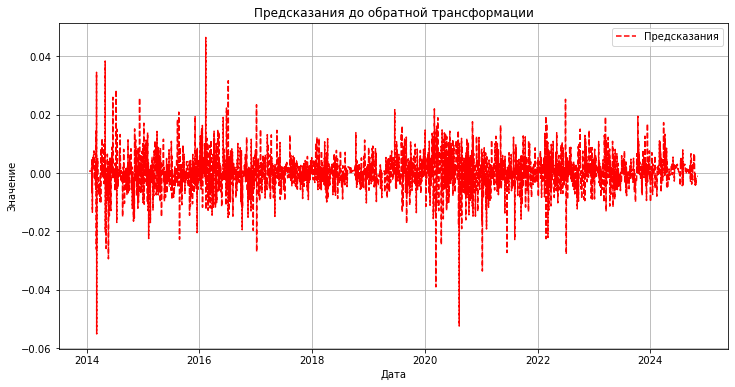

In [224]:
y_pred = xgb_model.predict(X_shifted)
y_pred_restored = inverse_transform_predictions(pd.Series(y_pred, index=y_shifted.index), y_c)
# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(y_shifted.index, y_pred, label="Предсказания", color="red", linestyle="--")
plt.title("Предсказания до обратной трансформации")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid()
plt.show()


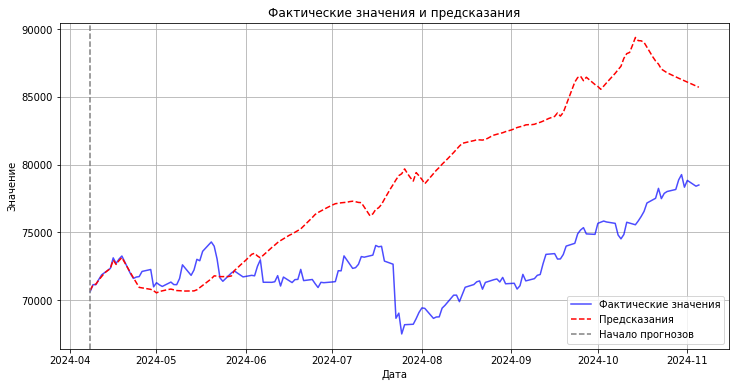

In [225]:
# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(y_shifted[train_size-pred_window:].index, y_c[1:][train_size-pred_window:], label="Фактические значения", color="blue", alpha=0.7)
plt.plot(y_shifted[train_size-pred_window:].index, y_pred_restored[train_size-pred_window:], label="Предсказания", color="red", linestyle="--")
plt.axvline(x=y_shifted[train_size-pred_window:].index[0], color="gray", linestyle="--", label="Начало прогнозов")
plt.title("Фактические значения и предсказания")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.grid()
plt.show()


## Проверка модели на кросс валидации

In [192]:
xgb_mse_scores = []
xgb_r2_scores = []
tscv = TimeSeriesSplit(n_splits=44)

for fold_idx, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_index]
    X_test  = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test  = y.iloc[test_index]

    xgb_model = XGBRegressor(
        n_estimators=100, 
        learning_rate=0.1, 
        random_state=42
    )
    xgb_model.fit(X_train, y_train)

    xgb_pred = xgb_model.predict(X_test)
    xgb_mse = mean_squared_error(y_test, xgb_pred)
    xgb_r2 = r2_score(y_test, xgb_pred)

    xgb_mse_scores.append(xgb_mse)
    xgb_r2_scores.append(xgb_r2)

print("Результаты XGBRegressor")
print(f"MSE: {np.mean(xgb_mse_scores):.4f} ± {np.std(xgb_mse_scores):.4f}")
print(f"R2:  {np.mean(xgb_r2_scores):.4f} ± {np.std(xgb_r2_scores):.4f}")

## Сравнение разных окон предсказания

Результаты XGBRegressor, с окном  1
MSE: 75561515.526760
R2:  -11.047943
Количество совпадений в динамике: 119
Всего дней для анализа: 198
Точность предсказания направления: 60.10%


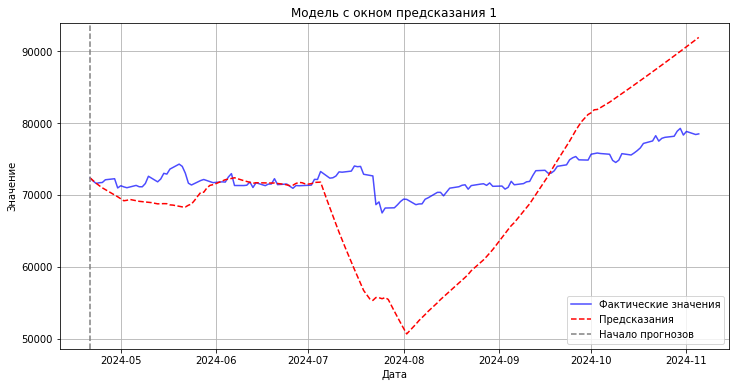

-------------------------------
Результаты XGBRegressor, с окном  2
MSE: 51266993.540306
R2:  -7.174291
Количество совпадений в динамике: 103
Всего дней для анализа: 199
Точность предсказания направления: 51.76%


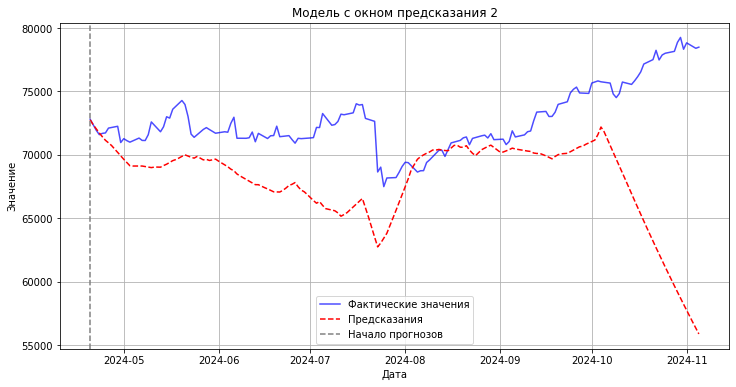

-------------------------------
Результаты XGBRegressor, с окном  3
MSE: 571025767.432780
R2:  -90.047488
Количество совпадений в динамике: 112
Всего дней для анализа: 200
Точность предсказания направления: 56.00%


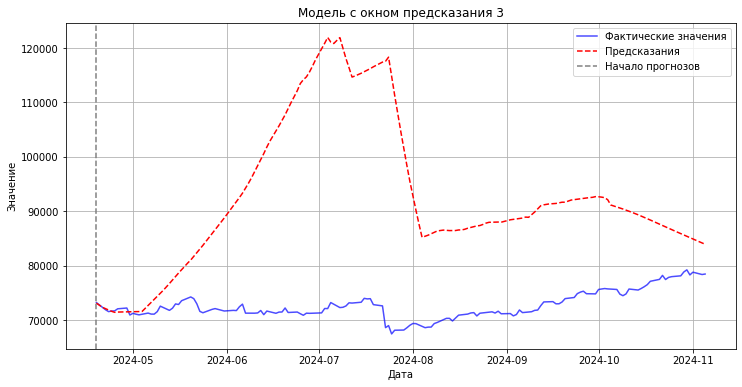

-------------------------------
Результаты XGBRegressor, с окном  4
MSE: 590969612.366383
R2:  -93.227444
Количество совпадений в динамике: 92
Всего дней для анализа: 201
Точность предсказания направления: 45.77%


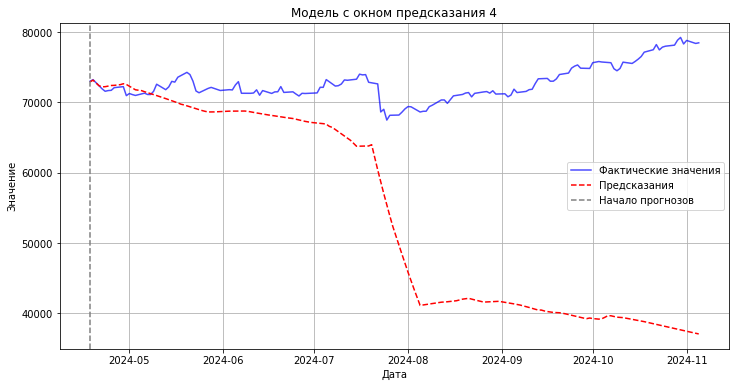

-------------------------------
Результаты XGBRegressor, с окном  5
MSE: 98006472.250226
R2:  -14.626691
Количество совпадений в динамике: 98
Всего дней для анализа: 202
Точность предсказания направления: 48.51%


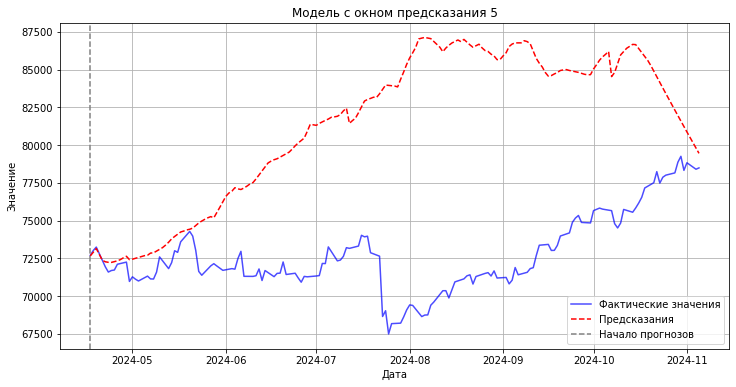

-------------------------------
Результаты XGBRegressor, с окном  6
MSE: 30177184.104509
R2:  -3.811616
Количество совпадений в динамике: 110
Всего дней для анализа: 203
Точность предсказания направления: 54.19%


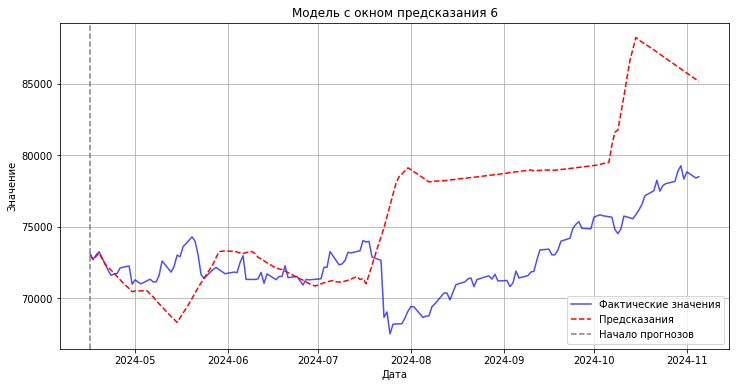

-------------------------------
Результаты XGBRegressor, с окном  7
MSE: 707326935.960747
R2:  -111.780096
Количество совпадений в динамике: 123
Всего дней для анализа: 204
Точность предсказания направления: 60.29%


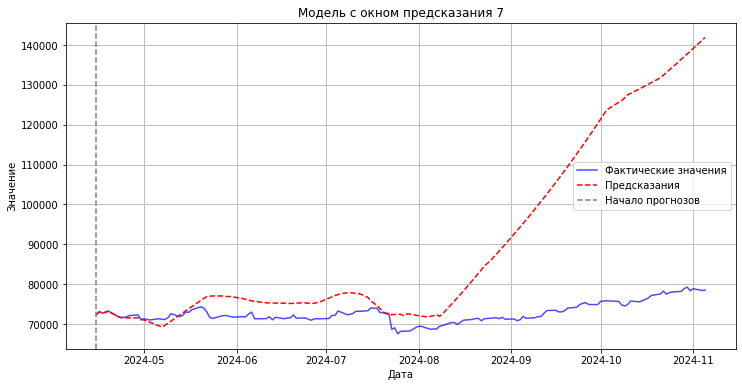

-------------------------------
Результаты XGBRegressor, с окном  8
MSE: 3399624623.978367
R2:  -541.054842
Количество совпадений в динамике: 118
Всего дней для анализа: 205
Точность предсказания направления: 57.56%


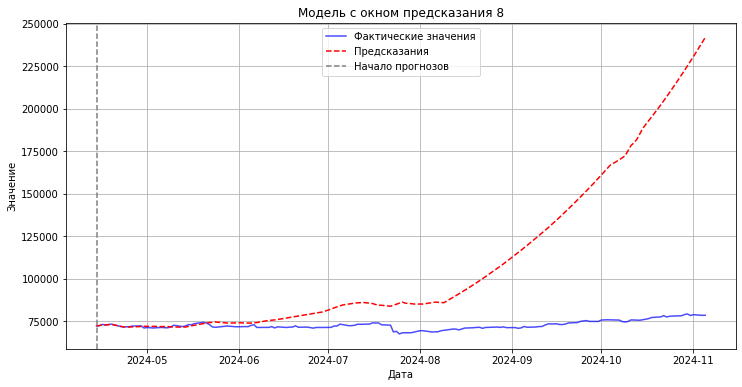

-------------------------------
Результаты XGBRegressor, с окном  9
MSE: 80266768.156787
R2:  -11.798175
Количество совпадений в динамике: 113
Всего дней для анализа: 206
Точность предсказания направления: 54.85%


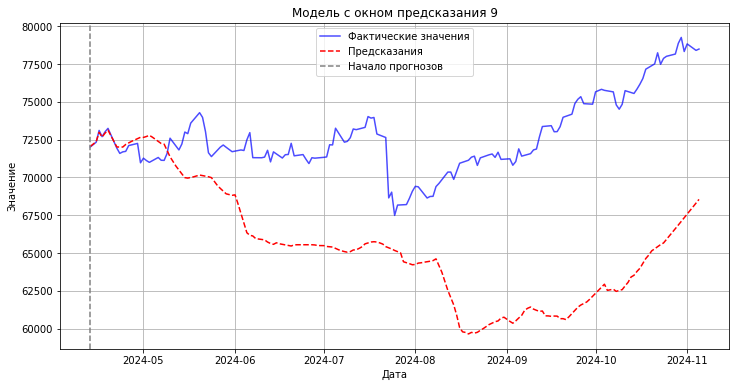

-------------------------------
Результаты XGBRegressor, с окном  10
MSE: 169977595.316673
R2:  -26.102162
Количество совпадений в динамике: 114
Всего дней для анализа: 207
Точность предсказания направления: 55.07%


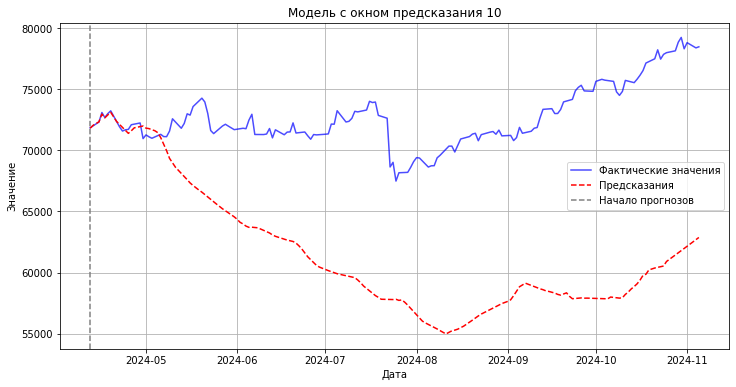

-------------------------------
Результаты XGBRegressor, с окном  14
MSE: 59323343.785000
R2:  -8.458840
Количество совпадений в динамике: 113
Всего дней для анализа: 211
Точность предсказания направления: 53.55%


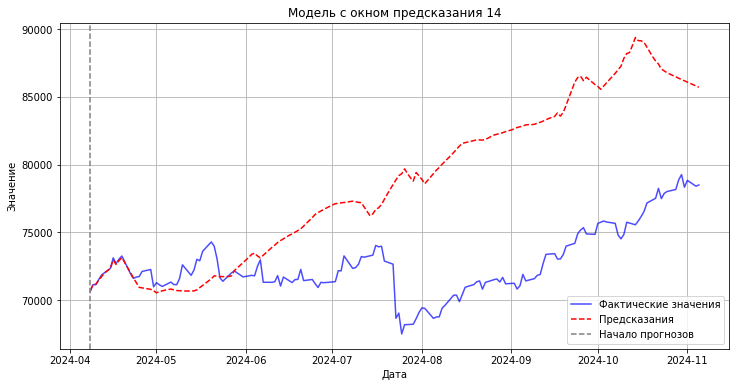

-------------------------------
Результаты XGBRegressor, с окном  30
MSE: 22796980.002625
R2:  -2.618200
Количество совпадений в динамике: 142
Всего дней для анализа: 226
Точность предсказания направления: 62.83%


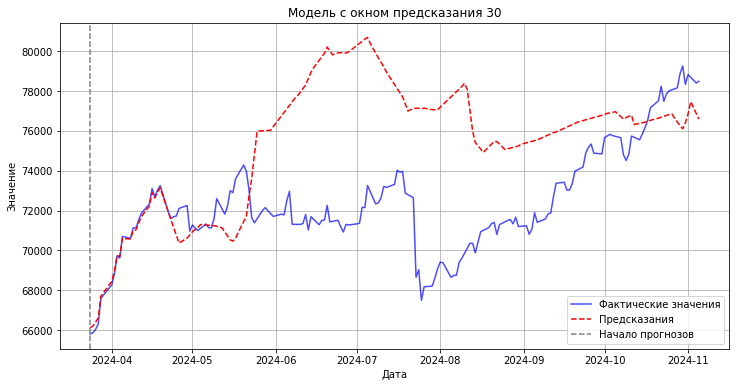

-------------------------------
Результаты XGBRegressor, с окном  60
MSE: 177847974.156882
R2:  -27.111604
Количество совпадений в динамике: 143
Всего дней для анализа: 255
Точность предсказания направления: 56.08%


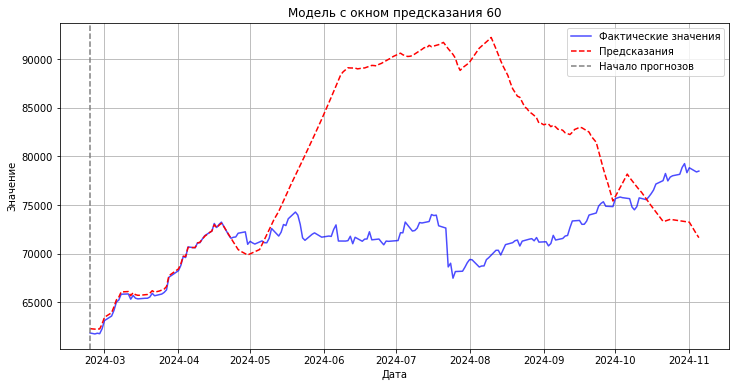

-------------------------------


In [237]:
for pred_window in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 14, 30, 60]:
    X_shifted = X[:-pred_window]
    y_shifted = y[pred_window:]

    y_c = y_shifted

    p_value_original = adfuller(y, autolag='AIC')[1]
    did_log_transform = False
    did_diff = False
    if p_value_original > 0.05:
        price_series_transformed = np.log(y_shifted)
        did_log_transform = True
    
        p_value_log = adfuller(price_series_transformed.dropna(), autolag='AIC')[1]
        if p_value_log > 0.05:
            price_series_transformed = price_series_transformed.diff().dropna()
            did_diff = True
        y_shifted = price_series_transformed.dropna()
    X_shifted = X_shifted[1:]

    train_size = int(len(X_shifted) * 0.95)
    X_train = X_shifted.iloc[:train_size]
    X_test  = X_shifted.iloc[train_size:]
    y_train = y_shifted.iloc[:train_size]
    y_test  = y_shifted.iloc[train_size:]

    
    xgb_model = XGBRegressor(
        n_estimators=1500, 
        max_depth=100, 
        learning_rate=0.01, 
    )
    xgb_model.fit(X_train, y_train)
    
    # Счиатем метрики
    y_pred = xgb_model.predict(X_test)
    y_pred_restored = inverse_transform_predictions(pd.Series(y_pred, index=y_shifted[train_size:].index), (y_c[1:])[train_size:])
    xgb_mse = mean_squared_error((y_c[1:])[train_size:], y_pred_restored)
    xgb_r2 = r2_score((y_c[1:])[train_size:], y_pred_restored)
    print("Результаты XGBRegressor, с окном ", pred_window)
    print(f"MSE: {(xgb_mse):.6f}")
    print(f"R2:  {(xgb_r2):.6f}")
    
    y_pred = xgb_model.predict(X_shifted)
    y_pred_restored = inverse_transform_predictions(pd.Series(y_pred, index=y_shifted.index), y_c)
    real_prices = y_c[1:][train_size-pred_window:]
    pred_prices = y_pred_restored[train_size-pred_window:]
    
    
    # Вычисляем дневную динамику (разности) и точность предсказаний
    real_dynamics = np.diff(real_prices)
    predicted_dynamics = np.diff(pred_prices) 
    correct_directions = (np.sign(real_dynamics) == np.sign(predicted_dynamics))
    correct_count = np.sum(correct_directions)

    print(f"Количество совпадений в динамике: {correct_count}")
    print(f"Всего дней для анализа: {len(real_dynamics)}")
    print(f"Точность предсказания направления: {correct_count / len(real_dynamics):.2%}")

    
    # Построение графика
    plt.figure(figsize=(12, 6))
    plt.plot(y_shifted[train_size-pred_window:].index, real_prices, label="Фактические значения", color="blue", alpha=0.7)
    plt.plot(y_shifted[train_size-pred_window:].index, pred_prices, label="Предсказания", color="red", linestyle="--")
    plt.axvline(x=y_shifted[train_size-pred_window:].index[0], color="gray", linestyle="--", label="Начало прогнозов")
    plt.title(f"Модель с окном предсказания {pred_window}")
    plt.xlabel("Дата")
    plt.ylabel("Значение")
    plt.legend()
    plt.grid()
    plt.show()
    print("-------------------------------")



In [236]:


# Baseline
actual_prices = real_prices
predicted_prices = np.arange(1, len(real_prices) + 1)

actual_dynamics = np.diff(actual_prices) 
predicted_dynamics = np.diff(predicted_prices)  

correct_directions = (np.sign(actual_dynamics) == np.sign(predicted_dynamics))

correct_count = np.sum(correct_directions)

print(f"Количество совпадений в динамике: {correct_count}")
print(f"Всего дней для анализа: {len(actual_dynamics)}")
print(f"Точность предсказания направления: {correct_count / len(actual_dynamics):.2%}")


Количество совпадений в динамике: 168
Всего дней для анализа: 255
Точность предсказания направления: 65.88%


In [ ]:
gg